In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Load data
customers = pd.read_csv('../data/sample/customers.csv')
accounts = pd.read_csv('../data/sample/accounts.csv')
transactions = pd.read_csv('../data/sample/transactions.csv')
aml_alerts = pd.read_csv('../data/sample/aml_alerts.csv')

In [4]:
print("=" * 80)
print("BANKING DATA EXPLORATION - Interview Insights")
print("=" * 80)

print("\n📊 CUSTOMER INSIGHTS")
print(f"Total customers: {len(customers):,}")
print(f"\nTop 5 nationalities:")
print(customers['nationality'].value_counts().head())
print(f"\nRisk distribution:")
print(customers['risk_category'].value_counts())

BANKING DATA EXPLORATION - Interview Insights

📊 CUSTOMER INSIGHTS
Total customers: 10,000

Top 5 nationalities:
India         2523
UAE           2008
Pakistan       984
Bangladesh     981
Egypt          784
Name: nationality, dtype: int64

Risk distribution:
LOW         7610
MEDIUM      1535
HIGH         687
CRITICAL     168
Name: risk_category, dtype: int64


In [11]:
!ls -l

total 64
-rw-r--r-- 1 jovyan users  5354 Feb 27 19:58 01_smoke_test.ipynb
-rw-r--r-- 1 jovyan users 54343 Feb 27 20:02 02_explore_generated_data.ipynb



✅ Saved visualization: docs/customer_segments.png


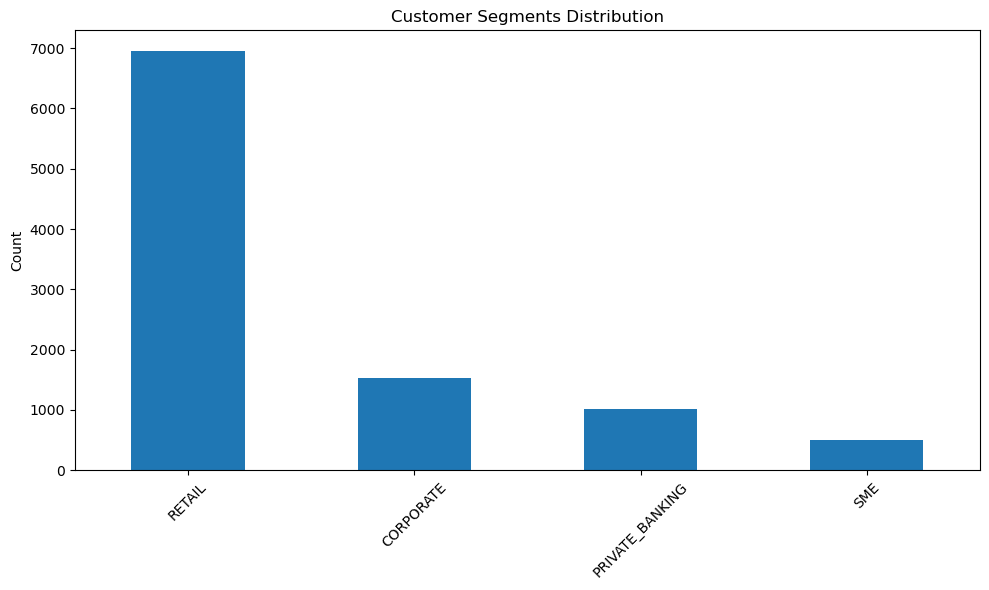

In [13]:
# Plot customer segments
plt.figure(figsize=(10, 6))
customers['customer_segment'].value_counts().plot(kind='bar')
plt.title('Customer Segments Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./customer_segments.png')
print("\n✅ Saved visualization: docs/customer_segments.png")

In [14]:
print("\n💳 TRANSACTION INSIGHTS")
transactions['transaction_timestamp'] = pd.to_datetime(transactions['transaction_timestamp'])
transactions['hour'] = transactions['transaction_timestamp'].dt.hour


💳 TRANSACTION INSIGHTS


✅ Saved visualization: docs/hourly_transactions.png


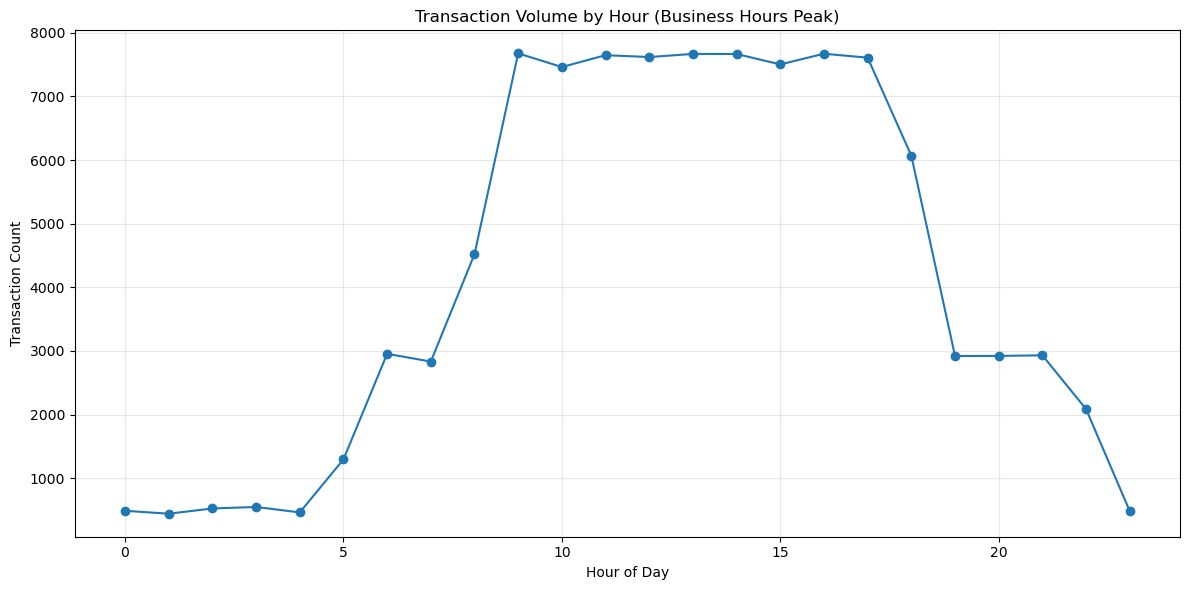

In [15]:
hourly_pattern = transactions.groupby('hour').size()
plt.figure(figsize=(12, 6))
hourly_pattern.plot(kind='line', marker='o')
plt.title('Transaction Volume by Hour (Business Hours Peak)')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./hourly_transactions.png')
print("✅ Saved visualization: docs/hourly_transactions.png")

In [16]:
print("\n🚨 AML ALERT INSIGHTS")
print(f"Total alerts: {len(aml_alerts):,}")
print(f"\nAlert types:")
print(aml_alerts['alert_type'].value_counts())
print(f"\nCritical alerts requiring immediate action: {(aml_alerts['severity'] == 'CRITICAL').sum()}")


🚨 AML ALERT INSIGHTS
Total alerts: 5,000

Alert types:
ROUND_AMOUNT              660
HIGH_VALUE_TRANSACTION    657
STRUCTURING               656
VELOCITY_ANOMALY          636
SANCTION_SCREENING        631
SUSPICIOUS_PATTERN        607
GEO_ANOMALY               588
PEP_MATCH                 565
Name: alert_type, dtype: int64

Critical alerts requiring immediate action: 306


✅ Saved visualization: docs/aml_alert_analysis.png


<Figure size 1400x800 with 0 Axes>

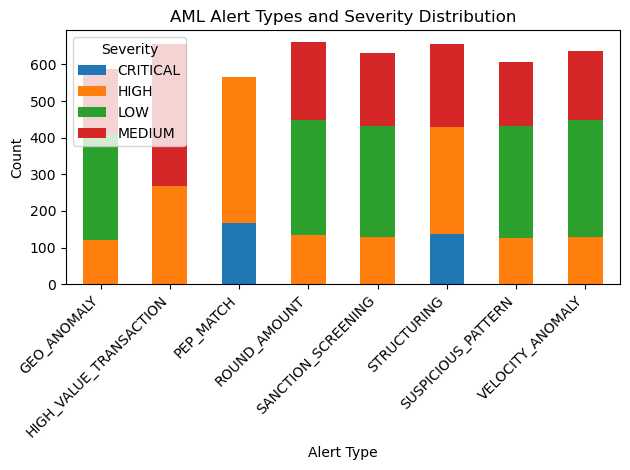

In [17]:
# Alert severity by type
alert_pivot = pd.crosstab(aml_alerts['alert_type'], aml_alerts['severity'])
plt.figure(figsize=(14, 8))
alert_pivot.plot(kind='bar', stacked=True)
plt.title('AML Alert Types and Severity Distribution')
plt.xlabel('Alert Type')
plt.ylabel('Count')
plt.legend(title='Severity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./aml_alert_analysis.png')
print("✅ Saved visualization: docs/aml_alert_analysis.png")